In [50]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

In [51]:
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]
y = (iris["target"] == 2).astype(np.float64)
svm_clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=1, loss="hinge")),
    ]
)
svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [52]:
svm_clf.predict([[5.5,1.7]])

array([1.])

In [53]:
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

X, y = make_circles(n_samples=2000, noise=0.1, random_state=42)

train_size = int(len(X) * 0.8)

polynomial_svm_clf = Pipeline(
    [
        ("poly_features", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        ("svm_clf", LinearSVC(C=10, loss="hinge")),
    ]
)

polynomial_svm_clf.fit(X[:train_size], y[:train_size])

c:\Users\Haji Suleman\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge'))])

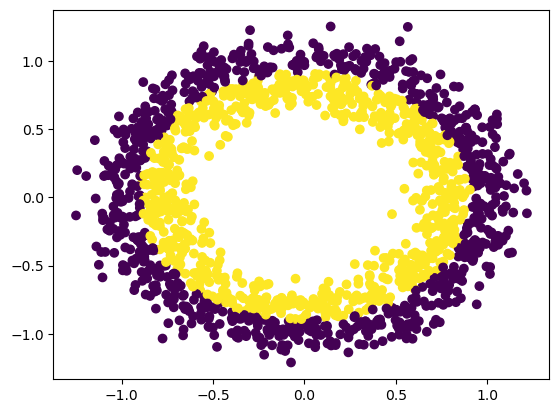

In [54]:
y_predicted = polynomial_svm_clf.predict(X[:train_size])
x_tester = X[:train_size]
plt.scatter(x_tester[:, 0], x_tester[:, 1],c=y_predicted)

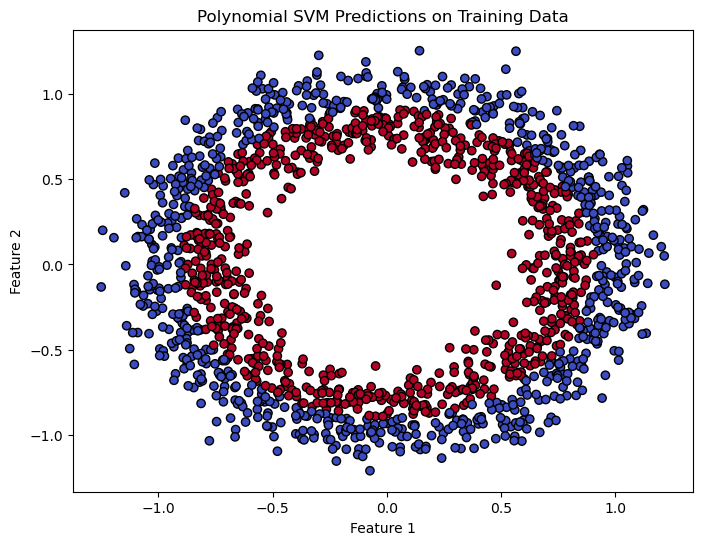

In [55]:
import matplotlib.pyplot as plt

y_predicted = polynomial_svm_clf.predict(X[:train_size])
x_tester = X[:train_size]

plt.figure(figsize=(8, 6))
plt.scatter(
    x_tester[:, 0], x_tester[:, 1], c=y_predicted, cmap="coolwarm", edgecolors="k"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Predictions on Training Data")
plt.savefig("./coolwarm.png")
plt.show()

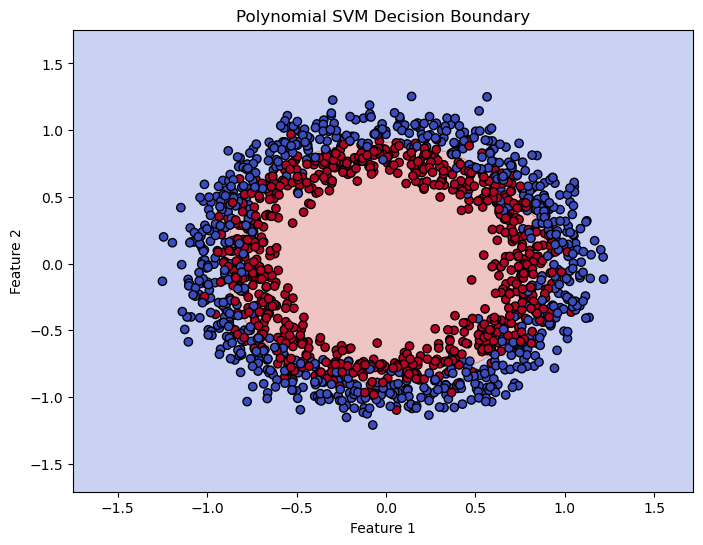

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Use your polynomial SVM and data
model = polynomial_svm_clf
X_plot = X[:train_size]
y_plot = y[:train_size]

# Create a mesh of points
x0_min, x0_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
x1_min, x1_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx0, xx1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 500), np.linspace(x1_min, x1_max, 500)
)

# Predict on the mesh points
mesh_points = np.c_[xx0.ravel(), xx1.ravel()]
Z = model.predict(mesh_points)
Z = Z.reshape(xx0.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(8, 6))
plt.contourf(xx0, xx1, Z, cmap="coolwarm", alpha=0.3)  # decision regions
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap="coolwarm", edgecolors="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Decision Boundary")
plt.savefig("Decision_boundary.png")
plt.show()

In [57]:
from sklearn.svm import SVC

poly_kernal_svm_clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5)),
    ]
)
poly_kernal_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

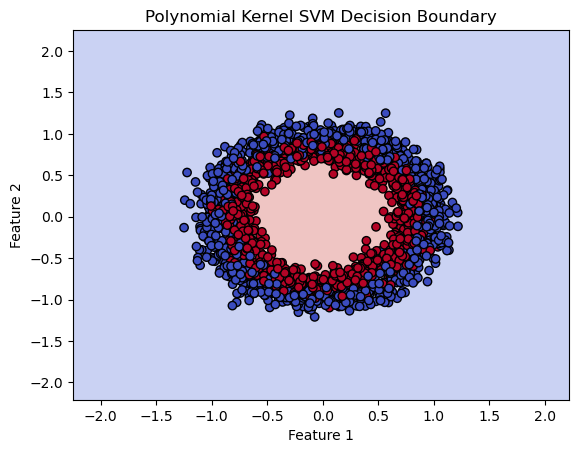

In [58]:

x0s = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500)
x1s = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500)

x0, x1 = np.meshgrid(x0s, x1s)
X_new = np.c_[x0.ravel(), x1.ravel()]

y_pred = poly_kernal_svm_clf.predict(X_new)
y_pred = y_pred.reshape(x0.shape)

plt.contourf(x0, x1, y_pred,cmap="coolwarm", alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y,cmap="coolwarm", edgecolors="k")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial Kernel SVM Decision Boundary")

plt.show()

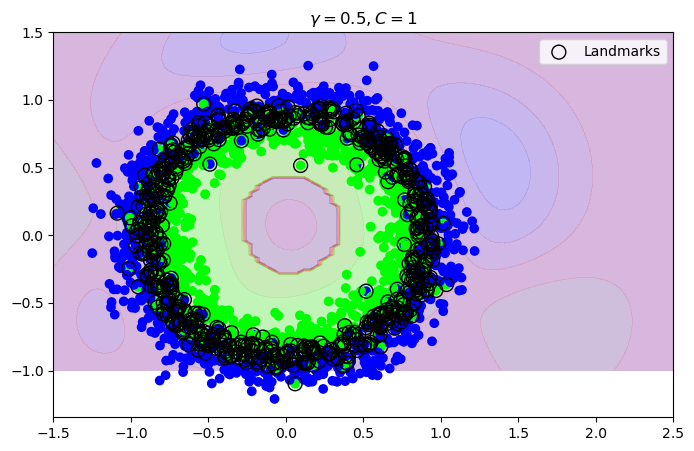

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# 1. Setup Plotting Function
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    y_decision = clf.decision_function(X_new).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)


# 2. Define and Fit your Pipeline (using your settings)
rbf_kernel_svm = Pipeline(
    [("scaler", StandardScaler()), ("svm_clf", SVC(kernel="rbf", gamma=1, C=50))]
)

# Assuming X and y are already defined
model = rbf_kernel_svm.fit(X, y)

# 3. Visualize the Result
plt.figure(figsize=(8, 5))
plot_predictions(rbf_kernel_svm, [-1.5, 2.5, -1, 1.5])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.brg)

# 4. Highlight the Landmarks (Support Vectors)
# Note: We must inverse transform to show them on the original scale
svm_step = rbf_kernel_svm.named_steps["svm_clf"]
scaler_step = rbf_kernel_svm.named_steps["scaler"]
landmarks = scaler_step.inverse_transform(svm_step.support_vectors_)

plt.scatter(
    landmarks[:, 0],
    landmarks[:, 1],
    s=100,
    facecolors="none",
    edgecolors="k",
    label="Landmarks",
)

plt.title(r"$\gamma = 0.5, C = 1$")
plt.legend()
plt.show()